# PyKoopman: Basic

> We use our training data to fit a DMD model by using **NO** observables and a single trajectory.

#### Imports

In [1]:
from ast import literal_eval

import matplotlib.pyplot as plt
import numpy as np
import numpy.random as rnd
import pykoopman as pk
from matrepr import mprint
from pydmd import DMD
from safetensors.torch import load_file

from learningdynamics.utils import safetensors_metadata_parser
from learningdynamics.dmd_dataset import reshape_interleave_time

In [2]:
# | hide
np.random.seed(42)  # for reproducibility
%matplotlib inline

#### Load data

In [3]:
file_path = "../saved_weights/states.safetensors"

metadata = safetensors_metadata_parser(file_path=file_path)
NUM_LOOP_ITERATIONS = literal_eval(metadata["NUM_LOOP_ITERATIONS"])
NUM_TRAJECTORIES = literal_eval(metadata["NUM_TRAJECTORIES"])
NUM_STATES = literal_eval(metadata["NUM_STATES"])

data = load_file(file_path)

#### Update dataset

The raw dataset can be truncated to use fewer loop iterations. We can also pick out the trajectories we are interested in

In [4]:
# train_idx = np.random.choice(NUM_TRAJECTORIES)
train_idx = 2

In [5]:
# test_idx = np.random.choice(NUM_TRAJECTORIES)
test_idx = 4

In [6]:
NUM_TRAJECTORIES = 1
NUM_LOOP_ITERATIONS = 100
RANK = 5

In [7]:
t = np.arange(0, NUM_LOOP_ITERATIONS, 1)

#### Learn Koopman Operator

Using time delay observables

In [8]:
train_states = reshape_interleave_time(
    data["train_states"][:NUM_LOOP_ITERATIONS, [train_idx], :]
)
test_states = reshape_interleave_time(
    data["test_states"][:NUM_LOOP_ITERATIONS, [test_idx], :]
)
observables = pk.observables.Identity()

In [9]:
# regressor = pk.regression.EDMD(svd_rank=RANK)
regressor = DMD(svd_rank=RANK)

# Time shift data
X = train_states[:, :-NUM_TRAJECTORIES].numpy()
Y = train_states[:, NUM_TRAJECTORIES:].numpy()

dmd_model = pk.Koopman(observables=observables, regressor=regressor)
dmd_model.fit(X.T, y=Y.T)

Koopman(observables=Identity(),
        regressor=PyDMDRegressor(regressor=<pydmd.dmd.DMD object at 0x7f7edf2fe080>))

In [10]:
train_states.shape

torch.Size([6, 50])

/tmp/ipykernel_2865/532360961.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1702400366987/work/aten/src/ATen/native/TensorShape.cpp:3614.)
  x0 = train_states[:, 0].T.numpy()
/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:292: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(self.A.dtype)


ValueError: x and y must have same first dimension, but have shapes (100,) and torch.Size([50])

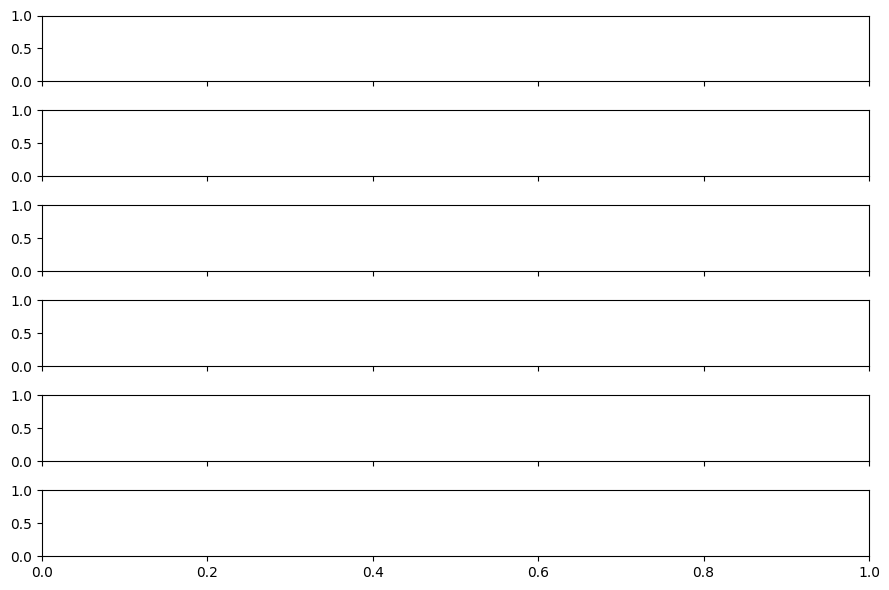

In [11]:
x0 = train_states[:, 0].T.numpy()
Xkoop = dmd_model.simulate(x0, n_steps=NUM_LOOP_ITERATIONS - 1)
Xkoop = np.vstack([x0, Xkoop])

fig, axs = plt.subplots(NUM_STATES, 1, sharex=True, tight_layout=True, figsize=(9, 6))

for state_idx in range(0, NUM_STATES):
    axs[state_idx].plot(
        t, train_states[state_idx, :], "-", color="b", label="True States"
    )
    axs[state_idx].plot(t, Xkoop[:, state_idx], "--r", label="Hankel DMD")
    axs[state_idx].set(ylabel=f"state {state_idx}")

axs[0].legend()

/usr/local/lib/python3.10/dist-packages/pykoopman/koopman.py:292: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(self.A.dtype)


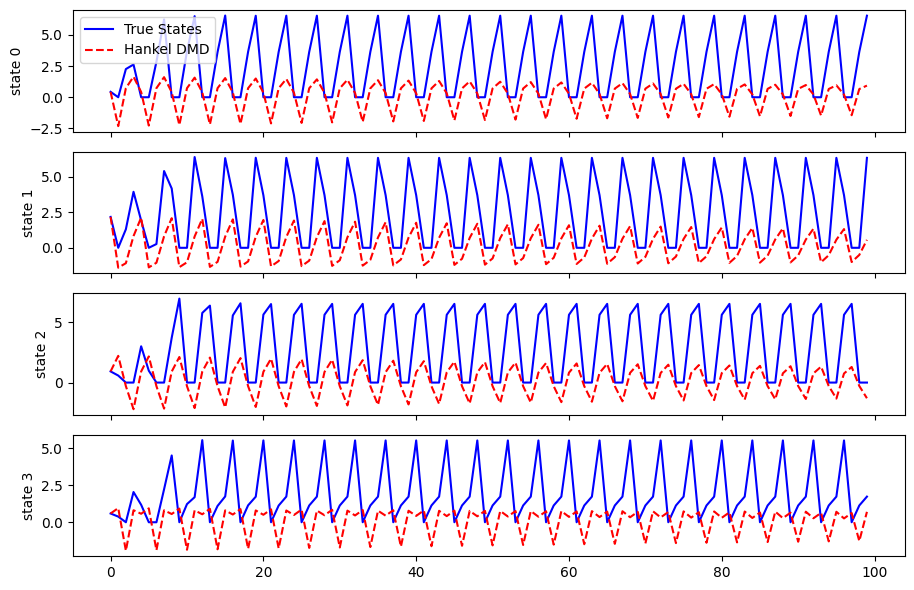

In [ ]:
x0 = test_states[:, 0].T.numpy()
Xkoop = dmd_model.simulate(x0, n_steps=NUM_LOOP_ITERATIONS - 1)
Xkoop = np.vstack([x0, Xkoop])

fig, axs = plt.subplots(NUM_STATES, 1, sharex=True, tight_layout=True, figsize=(9, 6))

for state_idx in range(0, NUM_STATES):
    axs[state_idx].plot(
        t, test_states[state_idx, :], "-", color="b", label="True States"
    )
    axs[state_idx].plot(t, Xkoop[:, state_idx], "--r", label="Hankel DMD")
    axs[state_idx].set(ylabel=f"state {state_idx}")

axs[0].legend()